# Train a Machine Learning Model
Experiment with Transformer, RNN, and Dense Neural Network Architectures and Preform Hyperparameter Tuning

### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [1]:
%matplotlib inline
import os
import random
import sys
sys.path.append(f"../Al_data")
from copy import deepcopy
from glob import glob
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import BayesianRidge, LinearRegression, Lasso, LassoLars
from sklearn.model_selection import(cross_validate, cross_val_predict, RepeatedKFold,
    GridSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from matminer.featurizers.function import FunctionFeaturizer
from stopping_power_ml.utils.io import load_qbox_data


2025-07-30 15:32:31.282391: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 15:32:31.285815: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 15:32:31.294336: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753907551.308841  708767 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753907551.313063  708767 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753907551.325111  708767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Utility Functions
Import custom utility functions for plotting and sequence preparation.

In [2]:
sys.path.append('./stopping-power-ML-reu/')
from nn_utilities import plot_training_history, plot_loglog_mae, create_datasets, prepare_sequences, plot_predictions_with_zoom

In [3]:
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Optional: Configure TensorFlow for deterministic behavior
    # This can slow down training but helps ensure reproducibility
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Enforce deterministic ops
    tf.config.experimental.enable_op_determinism()

set_seed(42)


In [4]:
import warnings; warnings.simplefilter('ignore')

## Load in the Dataset for Multiple Directions
Using data from 0_collect-datasets.ipynb.

In [7]:
data = pd.read_pickle(os.path.join('..', 'data', '0_2_atom_ion_mag', 'multiple_directions_0_2_atom_ion_mag.pkl.gz'))
print('Data set size:', len(data))

Data set size: 23600


In [8]:
featurizers = pkl.load(open(os.path.join('..','data', 'featurizers_chrg_1_atoms.pkl'), 'rb'))

Remove the initial transient

In [9]:
data.query('initial == False', inplace=True)
print('Training set size:', len(data))

Training set size: 23600


In [10]:
X_cols = featurizers.feature_labels()
X_cols = [col for col in featurizers.feature_labels() if col not in ['ion-ion_x', 'ion-ion_y', 'ion-ion_z']]
X_cols.append('ion-ion repulsion')

Determine which column is target

In [11]:
y_col = 'force'

Determine which columns are inputs

## A quick look at auto correlation
To determine if we should use a time-series optimized model such as convolutional or recurrent neural neworks, we see if energy and force (the two possible targets to predict) are correlated with themselves over time. We hypothesize that they are.


In [12]:
force_autocorr = data['force'].autocorr(lag=1)
print(f'Autocorrelation of force (lag=1): {force_autocorr:.4f}')

Autocorrelation of force (lag=1): 0.9980


In [13]:
energy_autocorr = data['energy'].autocorr(lag=1)
print(f'Autocorrelation of energy (lag=1): {energy_autocorr:.4f}')

Autocorrelation of energy (lag=1): 0.9995


This indeed shows a very strong correlation for force and a perfect correlation for energy. We will pursue models which work best for time-series data.

## Create batches and sliding window (Multiple directions)

In [14]:
batch_size = 128
timesteps = 10

from functools import reduce# Step 1: Split into train/validation (70/30 split)
unique_dirs = sorted(data['directory'].unique())
split_point = int(len(unique_dirs) * 0.7)
train_dirs = unique_dirs[:split_point]
val_dirs = unique_dirs[split_point:]# Re-run sequence creation loop separately for train and val
def build_sequences(subset_dirs, batch_size_per_dir):
    datasets = []    

    for d in subset_dirs:
        group = data[data['directory'] == d].sort_values('timestep')

        x = group[X_cols].values
        y = group[y_col].values        

        seqs = []
        targets = []

        for i in range(len(group) - timesteps):
            seqs.append(x[i:i+timesteps])
            targets.append(y[i+timesteps])        

        if len(seqs) == 0:
            continue  # skip this group if it doesn't have enough data

        X_dir = np.array(seqs)
        y_dir = np.array(targets).reshape(-1, 1)

        ds = tf.data.Dataset.from_tensor_slices((X_dir, y_dir))
        ds = ds.batch(batch_size_per_dir).prefetch(tf.data.AUTOTUNE)
        datasets.append(ds)

    if not datasets:
        raise ValueError("No datasets were built. Check subset_dirs and sequence logic.")

    return reduce(lambda a, b: a.concatenate(b), datasets)



In [15]:
for d in unique_dirs:
    n_timesteps = len(data[data['directory'] == d])
    if n_timesteps <= timesteps:
        print(f"Directory '{d}' has only {n_timesteps} timesteps — skipped")


In [16]:
print(f"Using {len(train_dirs)} training dirs and {len(val_dirs)} validation dirs.")

Using 2 training dirs and 2 validation dirs.


In [17]:
train_ds = build_sequences(train_dirs, batch_size)
val_ds = build_sequences(val_dirs, batch_size)

2025-07-30 15:33:26.487259: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Load data and create batches (individual directions)

In [18]:
random_data = pd.read_pickle(os.path.join('..', 'data', '0_2_atom_ion_mag', 'random_data_0_2_atom_ion_mag.pkl.gz'))
channel_data = pd.read_pickle(os.path.join('..', 'data', '0_2_atom_ion_mag', 'channel_data_0_2_atom_ion_mag.pkl.gz'))

In [19]:
random_data.query('initial == False', inplace=True)
print('Random direction training set size:', len(random_data))
channel_data.query('initial == False', inplace=True)
print('Channel direction training set size:', len(channel_data))

Random direction training set size: 9379
Channel direction training set size: 1579


In [20]:
X_cols = featurizers.feature_labels()
X_cols = [col for col in featurizers.feature_labels() if col not in ['ion-ion_x', 'ion-ion_y', 'ion-ion_z']]
X_cols.append('ion-ion repulsion')

Determine which column is target

In [21]:
y_col = 'force'

In [22]:
def prepare_sequence_datasets(
    data,
    X_cols,
    y_col,
    sequence_col='file_id',
    timestep_col='timestep',
    timesteps=5,
    batch_size=10,
    train_split=0.7,
):
    """
    Prepares train/val tf.data.Dataset from tabular time series data.

    Returns:
    - train_ds: tf.data.Dataset
    - val_ds: tf.data.Dataset
    - x_scaler: fitted StandardScaler for X
    - y_scaler: fitted StandardScaler for y
    - input_shape: tuple, shape of a single input sample (timesteps, num_features)
    """
    # Step 1: Scale features
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    data[X_cols] = x_scaler.fit_transform(data[X_cols])
    data[y_col] = y_scaler.fit_transform(data[[y_col]])

    sequences, targets = [], []

    # Step 2: Generate sequences
    for _, group in data.groupby(sequence_col):
        group = group.sort_values(timestep_col)
        x = group[X_cols].values
        y = group[y_col].values

        for i in range(len(group) - timesteps):
            sequences.append(x[i:i+timesteps])
            targets.append(y[i+timesteps])

    X = np.array(sequences)
    y = np.array(targets).reshape(-1, 1)

    # Step 3: Train/Validation Split
    num_samples = len(X)
    split_index = int(train_split * num_samples)

    X_train, y_train = X[:split_index], y[:split_index]
    X_val, y_val = X[split_index:], y[split_index:]

    # Step 4: Convert to tf.data.Dataset
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

    train_ds = train_ds.shuffle(buffer_size=len(X_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # Step 5: Derive input shape
    input_shape = (X.shape[1], X.shape[2])  # (timesteps, num_features)

    return train_ds, val_ds, x_scaler, y_scaler, input_shape, X, y

We extract and combine features and targets from both random_data and channel_data, then standardize them using StandardScaler to ensure consistent scaling. The scaled values are merged into a unified dataset (full_data), which is then used to generate sequential train/validation sets via prepare_sequence_datasets(...)

In [21]:
timesteps = 10
batch_size = 128
train_split = 0.5

# Step 1: Subset to X_cols and y_col
X_data = random_data[X_cols]
y_data = random_data[[y_col]]

X_channel = channel_data[X_cols]
y_channel = channel_data[[y_col]]

# Step 2: Concatenate raw inputs before scaling
X_full = pd.concat([X_data, X_channel], axis=0).reset_index(drop=True)
y_full = pd.concat([y_data, y_channel], axis=0).reset_index(drop=True)

# Step 3: Scale full data
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X_full)
y_scaled = y_scaler.fit_transform(y_full)

# Restore all the original columns for future steps
full_data = pd.concat([random_data, channel_data], axis=0).reset_index(drop=True)

# Replace X_cols and y_col with scaled values
full_data[X_cols] = X_scaled
full_data[y_col] = y_scaled
train_ds, val_ds, X_scaler, y_scaler, input_shape, X, y = prepare_sequence_datasets(
    full_data,
    X_cols,
    y_col,
    sequence_col='file_id',
    timestep_col='timestep',
    timesteps=timesteps,
    batch_size=128,
    train_split=0.5,
)

full_data.shape

(10958, 40)

## Tune Hyperparameters for Transformer Model

This cell defines a lightweight Transformer-based regression model with optional positional embeddings and uses randomized hyperparameter search to evaluate multiple configurations. It includes custom layers, a random sampler that filters invalid setups (e.g. embed_dim % num_heads != 0), and a training loop with early stopping. After all trials, the best-performing configuration is printed along with its validation MAE. The emojis were just for fun.

### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [23]:
import os
import datetime
import random
import tensorflow as tf
import tensorflow.keras.backend as K

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, Add,
    GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Layer
)


class TransformerEncoder(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TimePositionalEmbedding(Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.pos_embedding = Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_embedding(positions)
        return x + pos_encoding

GOOD_EMOJIS = ["🔥", "🚀", "🌟", "🎉", "✨", "🤑", "👌"]
MEDIUM_EMOJIS = ["🤔", "🔍", "🕵️", "🧩", "🔎", "🛠️"]
BAD_EMOJIS = ["💀", "😵", "☠️", "😞", "😟", "⚠️"]

all_maes = []
def pick_emoji(mae, best_mae, worst_mae):
    if worst_mae == best_mae:
        score = 0
    else:
        score = (mae - best_mae) / (worst_mae - best_mae)

    if score <= 0.33:
        return random.choice(GOOD_EMOJIS)
    elif score <= 0.66:
        return random.choice(MEDIUM_EMOJIS)
    else:
        return random.choice(BAD_EMOJIS)

search_space = {
    'embed_dim': [8, 16, 32, 64],
    'num_heads': [1, 2, 4, 8],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
    'use_positional_embedding': [True, False]
}

def random_sample_combinations(space, num_samples=30):
    valid_combinations = []
    attempts = 0
    max_attempts = 500

    while len(valid_combinations) < num_samples and attempts < max_attempts:
        embed_dim = random.choice(space['embed_dim'])
        num_heads = random.choice(space['num_heads'])
        dropout_rate = random.choice(space['dropout_rate'])
        learning_rate = random.choice(space['learning_rate'])
        use_positional_embedding = random.choice(space['use_positional_embedding'])

        if embed_dim % num_heads != 0:
            attempts += 1
            continue

        ff_dim = random.choice([embed_dim, 2 * embed_dim, 4 * embed_dim])

        config = {
            'embed_dim': embed_dim,
            'num_heads': num_heads,
            'ff_dim': ff_dim,
            'dropout_rate': dropout_rate,
            'learning_rate': learning_rate,
            'use_positional_embedding': use_positional_embedding,
        }
        valid_combinations.append(config)
        attempts += 1

    if len(valid_combinations) < num_samples:
        print(f"Warning: Only generated {len(valid_combinations)} valid configs out of requested {num_samples}")

    return valid_combinations

def build_transformer_model(input_shape, embed_dim=8, num_heads=2, ff_dim=16, dropout_rate=0.2, use_positional_embedding=True):
    inputs = Input(shape=input_shape)
    x = Dense(embed_dim)(inputs)
    if use_positional_embedding:
        x = TimePositionalEmbedding(sequence_length=input_shape[0], embed_dim=embed_dim)(x)
    x = TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)
    return Model(inputs=inputs, outputs=outputs)

def run_transformer_search(input_shape, train_ds, val_ds, trials=30):
    best_mae = float('inf')
    best_config = None
    results = []

    configs = random_sample_combinations(search_space, trials)

    for i, config in enumerate(configs):
        print(f"\n🧪 Trial {i+1}/{len(configs)} with config:\n{config}")
        K.clear_session()

        model = build_transformer_model(
            input_shape=input_shape,
            embed_dim=config['embed_dim'],
            num_heads=config['num_heads'],
            ff_dim=config['ff_dim'],
            dropout_rate=config['dropout_rate'],
            use_positional_embedding=config['use_positional_embedding']
        )

        optimizer = tf.keras.optimizers.Adam(learning_rate=config['learning_rate'])
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=70,
            callbacks=callbacks,
            verbose=0
        )

        val_mae = min(history.history['val_mae'])
        results.append((config, val_mae))
        all_maes.append(val_mae)

        current_best_mae = min(all_maes)
        current_worst_mae = max(all_maes)
        emoji = pick_emoji(val_mae, current_best_mae, current_worst_mae)
        print(f"\n{emoji} Trial {i+1} finished — Validation MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            best_config = config

    print("\n🏆 Best Configuration Found:")
    print(best_config)
    print(f"🎯 Best Validation MAE: {best_mae:.4f}")

    return best_config, results


In [24]:
# Get one batch from the training dataset
for X_batch, y_batch in train_ds.take(1):
    input_shape = X_batch.shape[1:]  # exclude batch size

print("Input shape:", input_shape)


Input shape: (10, 27)


2025-07-30 15:33:41.271777: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
best_config, all_results = run_transformer_search(input_shape, train_ds, val_ds, trials=30)

## Train Transformer Hyperparameters

Uses `train_ds` and `val_ds` created from either multiple directions or single directions. Training the transformer model on multiple directions consistently yielded high MAE (usually 0.6 at best) indicating regular regression may be better for this task. Training on a single velocity however yielded consistently low MAE (0.02 at best) which is expected. Neither dataset generalized well when predicting force.

Here's saved best results from a previous test

In [26]:
best_config = {'embed_dim': 64, 'num_heads': 2, 'ff_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'use_positional_embedding': True}

In [27]:
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping

K.clear_session()

optimizer = tf.keras.optimizers.Adam(learning_rate=best_config['learning_rate'])

transformer_model = build_transformer_model(
    input_shape=input_shape,
    embed_dim=best_config['embed_dim'],
    num_heads=best_config['num_heads'],
    ff_dim=best_config['ff_dim'],
    dropout_rate=best_config['dropout_rate'],
    use_positional_embedding=best_config['use_positional_embedding']
)

transformer_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_mae', restore_best_weights=True, patience=50)

history = transformer_model.fit(
    train_ds,
    epochs=200, 
    validation_data=val_ds,
    callbacks=[early_stop]
)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.5211 - mae: 0.4817 - val_loss: 5.8823 - val_mae: 0.6569
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3045 - mae: 0.2999 - val_loss: 5.9319 - val_mae: 0.6383
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.3036 - mae: 0.2676 - val_loss: 5.8503 - val_mae: 0.6409
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.2675 - mae: 0.2732 - val_loss: 5.8366 - val_mae: 0.6573
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.2211 - mae: 0.2487 - val_loss: 5.8774 - val_mae: 0.6423
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1909 - mae: 0.2218 - val_loss: 5.8668 - val_mae: 0.6368
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1736 - mae: 0.2298 - val_loss: 5.9817 - val_mae: 0.6846
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1151 - mae: 0.1853 - val_loss: 5.9040 - val_mae: 0.6432
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - lo

### Visualize Transformer model

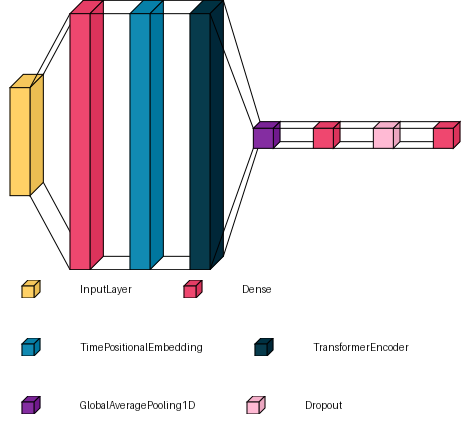

In [26]:
import visualkeras

# Build model
transformer_model = build_transformer_model(
    input_shape=input_shape,
    embed_dim=best_config['embed_dim'],
    num_heads=best_config['num_heads'],
    ff_dim=best_config['ff_dim'],
    dropout_rate=best_config['dropout_rate'],
    use_positional_embedding=best_config['use_positional_embedding']
)

# Generate image with legend
img = visualkeras.layered_view(
    transformer_model,
    legend=True,
    spacing=40#, to_file="transformer.png"
)

# Display in notebook
from IPython.display import display
display(img)


### Plot training history and loss functions

###  Training Visualization
Plot model training and validation loss over epochs.

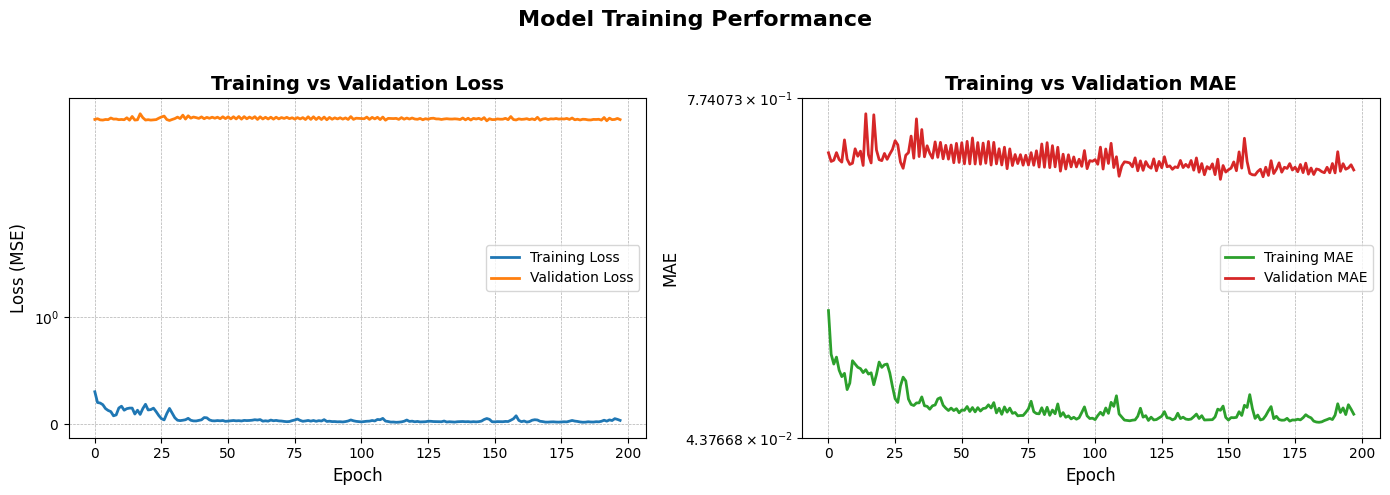

In [27]:
plot_training_history(history, log_scale=True)

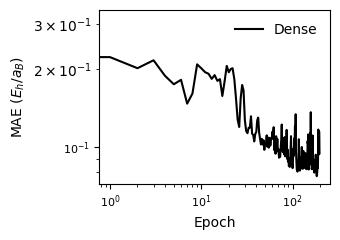

In [28]:
plot_loglog_mae(history)

### Test transformer model on **Multiple Directions** dataset

We found poor results generalizing to new directions with the LSTM Model

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

31/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

2025-07-30 15:44:17.085440: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Plot of 0


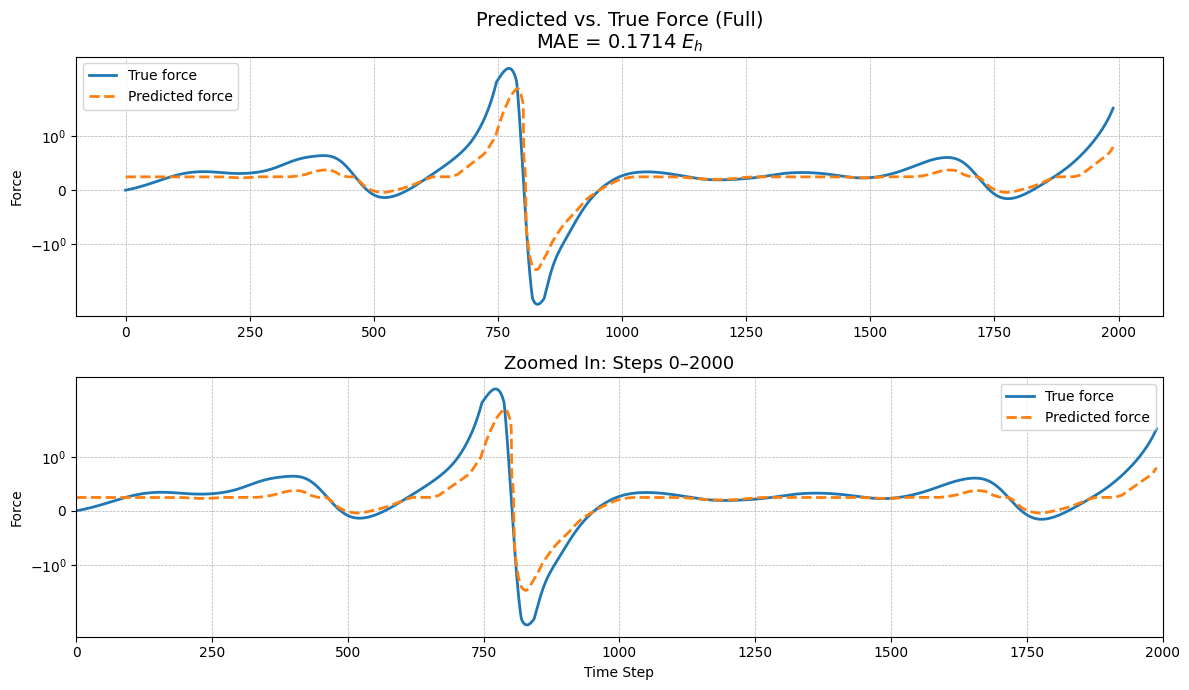

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Plot of 1


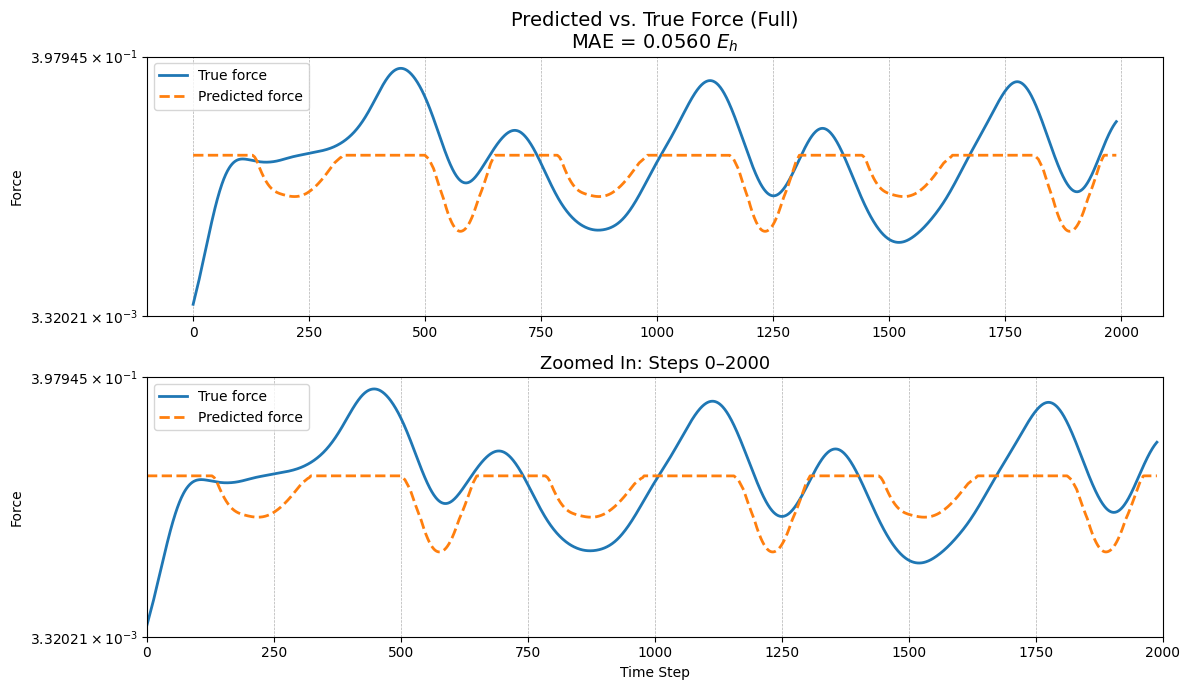

 96/306 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-07-30 15:44:24.313411: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Plot of 2


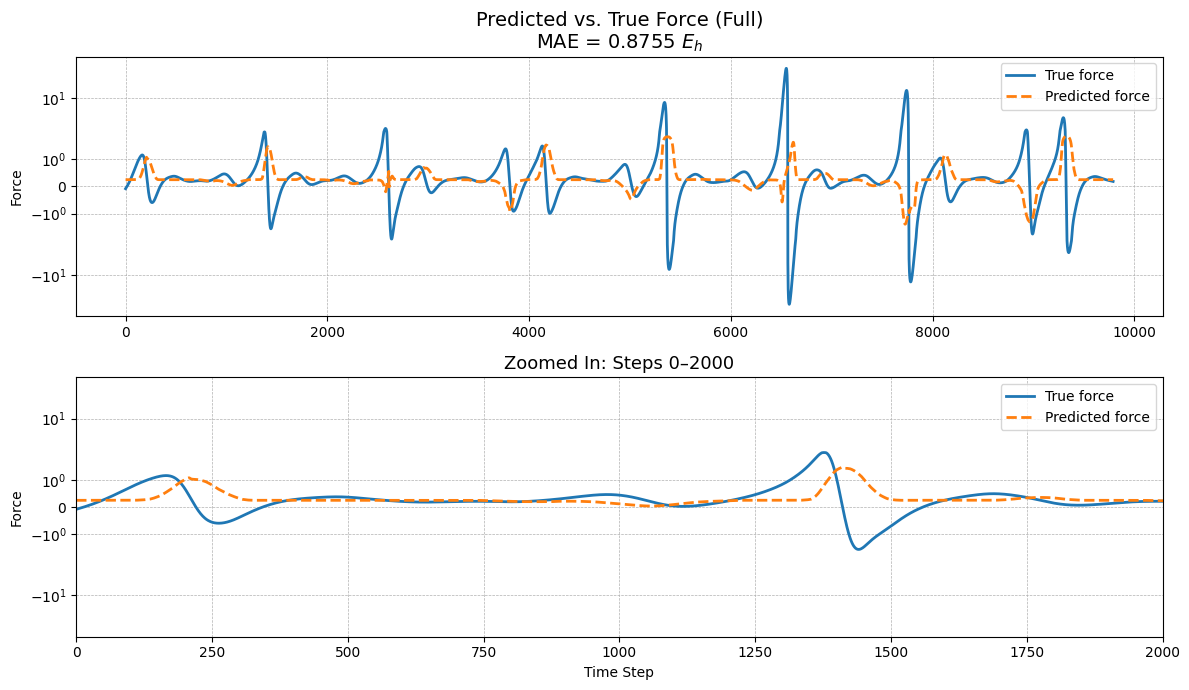

 98/306 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-07-30 15:44:30.288122: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Plot of 3


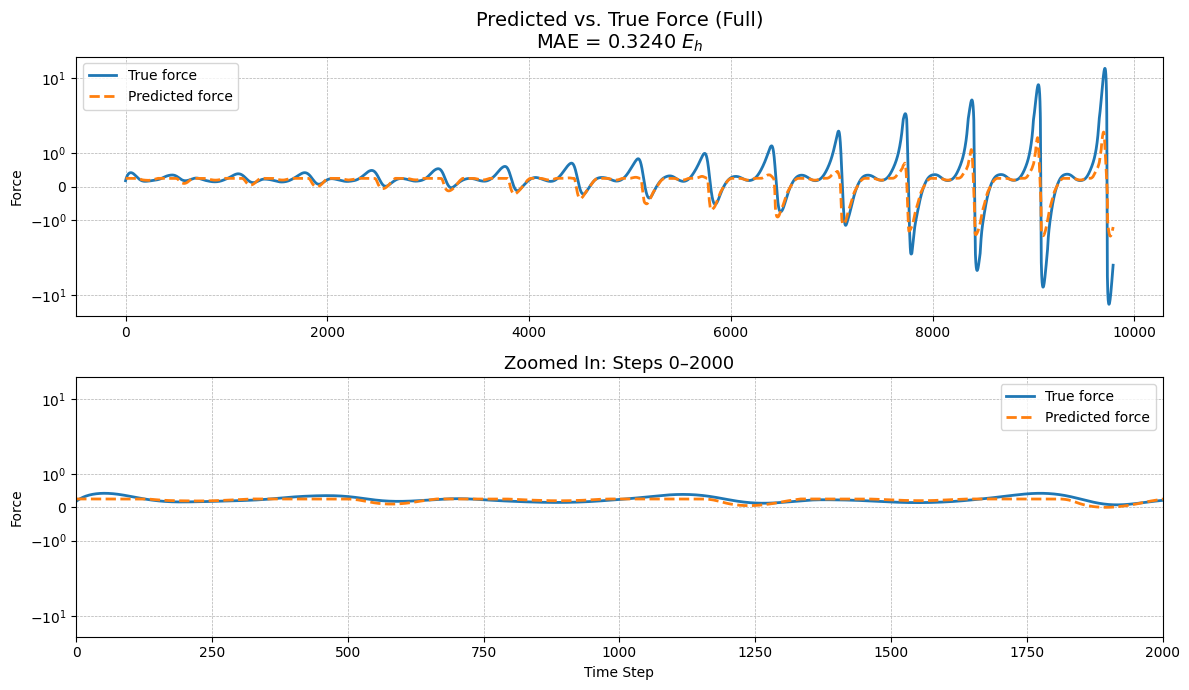

In [29]:
all_dirs = {
    #'datasets/256_Al/Dv1.0',
    #'datasets/Al_256_channel/Dv1.0',
    'datasets/Al_256_new/Dmin_v1.0',
    'datasets/Al_256_new/Dmod_v1.0',
    'datasets/Al_256_new/Doptimal_v1.0',
    'datasets/Al_256_new/Drnddir2_v1.0'
}

all_dirs = list(all_dirs)
for d in range(len(all_dirs)):
    new_file_df = data[data['file'] == all_dirs[d]]

    # Make sure it's sorted by timestep
    new_file_df = new_file_df.sort_values('timestep')
    channel_new_file_df = new_file_df.sort_values('timestep')
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    
    y_pred = transformer_model.predict(X_pred)  # shape: (num_windows, 1)
    y_pred = y_pred.flatten()
    print(f"Plot of {d}") 
    plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(0, 2000),
    log_scale=True
)

In [30]:
# Load new data — it should look like your original df
random_new_file_df = random_data[random_data['file'] == 'datasets/256_Al/Dv1.0']

# new_file_df = data[data['file'] == 'datasets/Al_256_new/Dmin_v1.0']

# Make sure it's sorted by timestep
random_new_file_df = new_file_df.sort_values('timestep')
channel_new_file_df = new_file_df.sort_values('timestep')

In [31]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)


In [32]:
y_pred = transformer_model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()


306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Random Data

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

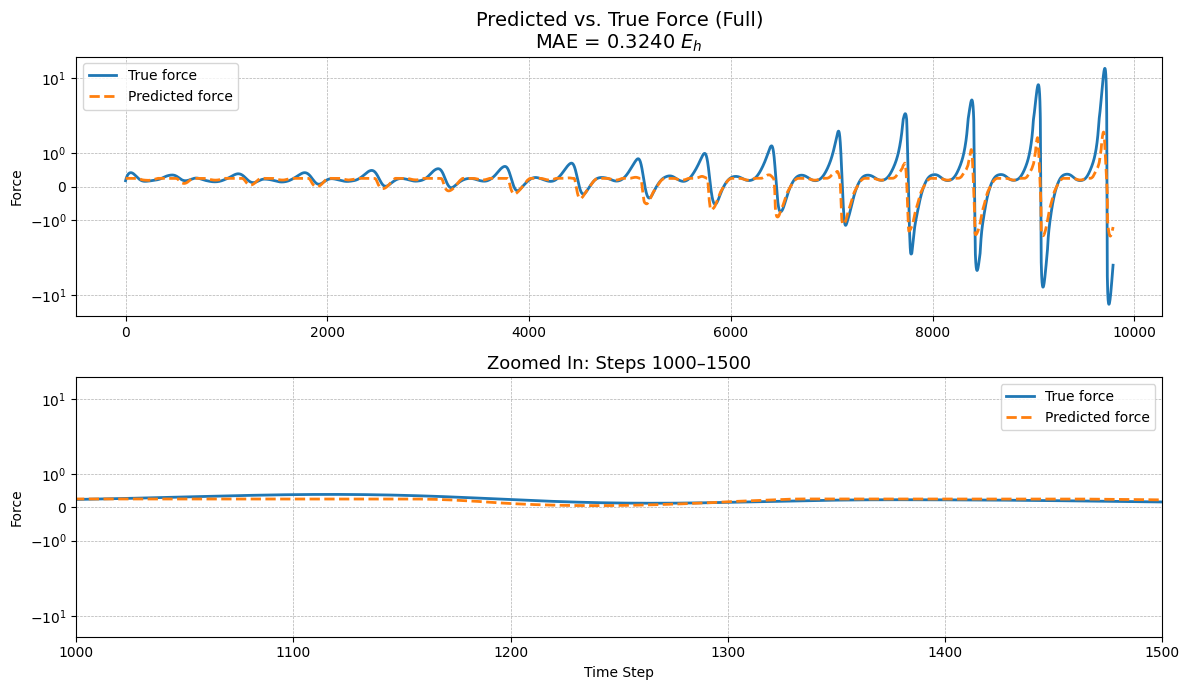

In [33]:
plot_predictions_with_zoom(
    y_true=random_new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(1000, 1500),
    log_scale=True
)


In [34]:
# Load new data — it should look like your original df
new_file_df = channel_data[channel_data['file'] == 'datasets/Al_256_channel/Dv1.0']

# Make sure it's sorted by timestep
new_file_df = new_file_df.sort_values('timestep')
channel_new_file_df = new_file_df.sort_values('timestep')

In [35]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)


In [36]:
y_pred = transformer_model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-07-30 15:44:52.752411: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Channel Data

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

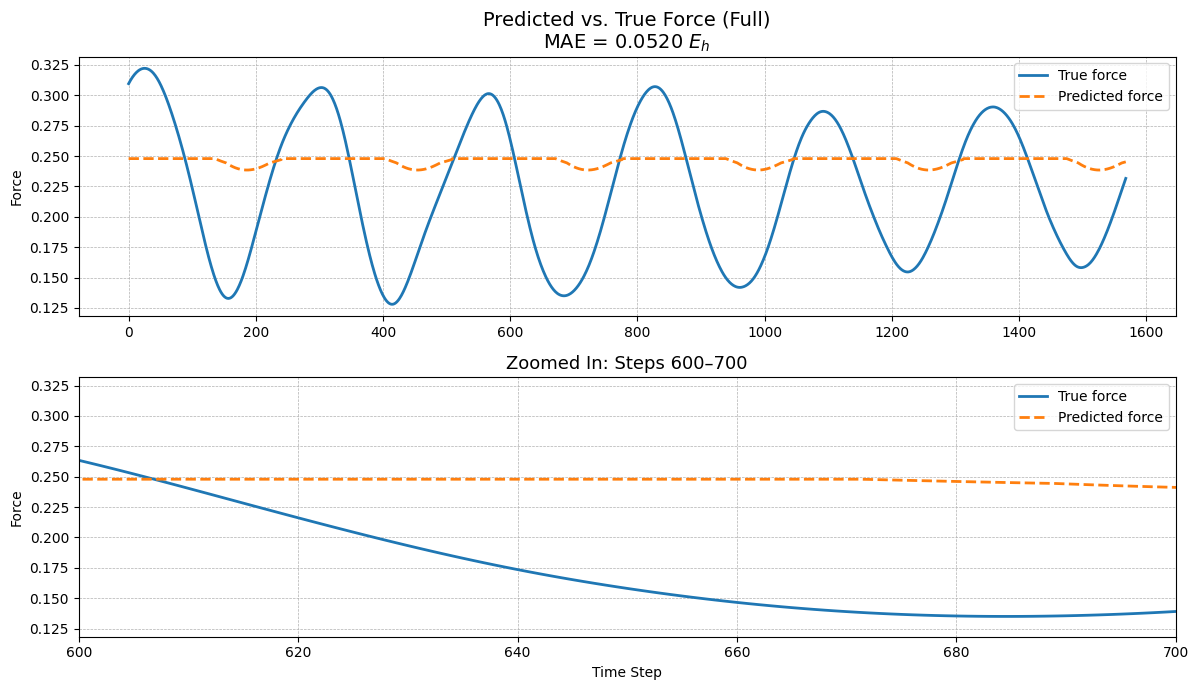

In [37]:
plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(600, 700),
    log_scale=False
)

## Tune Parameters for Recurrent Neural Network

### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation, Bidirectional, Normalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import numpy as np
import random

# === Search Space ===
search_space = {
    'lstm_units': [4, 8, 16, 32, 64],
    'dropout_rate': [0.1, 0.2],
    'dense_units': [0, 4, 8, 16, 32],
    'learning_rate': [1e-4, 3e-4, 1e-3],
    'l1_kernel': [0.0, 0.001, 0.005],
    'l1_recurrent': [0.0, 0.001, 0.005],
    'activation': ['relu']
}

# === Random Config Sampler ===
def random_sample_configs(space, num_trials=10):
    configs = []
    for _ in range(num_trials):
        config = {
            'lstm_units': random.choice(space['lstm_units']),
            'dropout_rate': random.choice(space['dropout_rate']),
            'dense_units': random.choice(space['dense_units']),
            'learning_rate': random.choice(space['learning_rate']),
            'l1_kernel': random.choice(space['l1_kernel']),
            'l1_recurrent': random.choice(space['l1_recurrent']),
            'activation': random.choice(space['activation'])
        }
        configs.append(config)
    return configs

# === Model Builder ===
def build_bidirectional_lstm_model(input_shape, config, norm_layer):
    kernel_reg = regularizers.L1(config['l1_kernel']) if config['l1_kernel'] > 0 else None
    recurrent_reg = regularizers.L1(config['l1_recurrent']) if config['l1_recurrent'] > 0 else None

    model = Sequential()
    model.add(norm_layer)

    model.add(Bidirectional(
        LSTM(config['lstm_units'], # Change to constant 8
             return_sequences=False,
             kernel_regularizer=kernel_reg,
             recurrent_regularizer=recurrent_reg),
        input_shape=input_shape
    ))
    if config['dense_units'] != 0:
        model.add(Dropout(0.2))
        model.add(Dense(config['dense_units'])) # Change to 8 constant
        model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))  # Output: regression scalar

    return model

# === Hyperparameter Search Runner ===
def run_bidirectional_lstm_search(input_shape, train_ds, val_ds, num_trials=60):
    # Build normalization layer from first batch
    norm_layer = Normalization()
    for batch_x, _ in train_ds.take(1):
        batch_flat = tf.reshape(batch_x, [-1, input_shape[-1]])
        norm_layer.adapt(batch_flat)

    best_mae = float('inf')
    best_config = None
    results = []

    configs = random_sample_configs(search_space, num_trials)

    for i, config in enumerate(configs):
        print(f"\n🔁 Trial {i+1}/{num_trials} | Config: {config}")
        K.clear_session()

        model = build_bidirectional_lstm_model(input_shape, config, norm_layer)
        optimizer = tf.keras.optimizers.Adam(learning_rate=config['learning_rate'])
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=70,
            callbacks=[early_stop],
            verbose=0
        )

        val_mae = min(history.history['val_mae'])
        print(f"✅ Trial {i+1} finished — Best Validation MAE: {val_mae:.4f}")
        results.append((config, val_mae))

        if val_mae < best_mae:
            best_mae = val_mae
            best_config = config

    print("\n🏆 Best Configuration Found:")
    print(best_config)
    print(f"🎯 Best Validation MAE: {best_mae:.4f}")

    return best_config, results



In [ ]:
best_config, results = run_bidirectional_lstm_search(input_shape, train_ds, val_ds)

2025-07-30 15:29:46.276436: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



🔁 Trial 1/60 | Config: {'lstm_units': 8, 'dropout_rate': 0.1, 'dense_units': 0, 'learning_rate': 0.001, 'l1_kernel': 0.001, 'l1_recurrent': 0.001, 'activation': 'relu'}
✅ Trial 1 finished — Best Validation MAE: 0.6508

🔁 Trial 2/60 | Config: {'lstm_units': 32, 'dropout_rate': 0.2, 'dense_units': 0, 'learning_rate': 0.001, 'l1_kernel': 0.005, 'l1_recurrent': 0.005, 'activation': 'relu'}
✅ Trial 2 finished — Best Validation MAE: 0.6050

🔁 Trial 3/60 | Config: {'lstm_units': 4, 'dropout_rate': 0.2, 'dense_units': 8, 'learning_rate': 0.0001, 'l1_kernel': 0.0, 'l1_recurrent': 0.0, 'activation': 'relu'}
✅ Trial 3 finished — Best Validation MAE: 0.6650

🔁 Trial 4/60 | Config: {'lstm_units': 64, 'dropout_rate': 0.2, 'dense_units': 4, 'learning_rate': 0.0003, 'l1_kernel': 0.0, 'l1_recurrent': 0.001, 'activation': 'relu'}
✅ Trial 4 finished — Best Validation MAE: 0.6637

🔁 Trial 5/60 | Config: {'lstm_units': 8, 'dropout_rate': 0.1, 'dense_units': 16, 'learning_rate': 0.001, 'l1_kernel': 0.0, 'l

## Test Best Recurrent Neural Network parameters

Using best_config from previous hyperparameter search

In [39]:
best_config = {'lstm_units': 32, 'dropout_rate': 0.1, 'dense_units': 32, 'learning_rate': 0.001, 'l1_kernel': 0.005, 'l1_recurrent': 0.005, 'activation': 'relu'}

### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [40]:
import numpy as np
from tensorflow.keras.layers import Normalization

# Step 1: Extract all X from train_ds
all_X = []

for X_batch, _ in train_ds:
    all_X.append(X_batch.numpy())  # Convert from tf.Tensor to NumPy

# Step 2: Concatenate and flatten
X_all = np.concatenate(all_X, axis=0)         # shape: (total_samples, timesteps, num_features)
X_flat = X_all.reshape(-1, X_all.shape[-1])   # shape: (total_samples * timesteps, num_features)

# Step 3: Create and adapt normalization layer
norm_layer = Normalization()
norm_layer.adapt(X_flat)  # Now norm_layer is ready to be used in your model

# Get one batch from the training dataset
for X_batch, y_batch in train_ds.take(1):
    input_shape = X_batch.shape[1:]  # exclude batch size

print("Input shape:", input_shape)

Input shape: (10, 27)


2025-07-30 15:45:03.015712: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN, Normalization, BatchNormalization, Activation
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, Activation, Normalization
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K
from tensorflow.keras import Input

norm_layer = Normalization()
norm_layer.adapt(X_flat)  # learns mean/std for each feature across time and samples

# ======== Previous Model builds ===========
# model = Sequential([
#     norm_layer,
#     LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=True),
#     Dropout(0.2),
#     LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
#     Dense(32), #, activation='relu'), # removed relu since target can be negative
#     Dropout(0.2),
#     Dense(1)
# ])

# model = Sequential([
#     norm_layer,
#     LSTM(64, input_shape=(X.shape[1], X.shape[2])),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(1)
# ])
#{'lstm_units': 16, 'dropout_rate': 0.1, 'dense_units': 32, 'learning_rate': 0.001, 'l1_kernel': 0.005, 'l1_recurrent': 0.0, 'activation': 'relu'}



def build_bidirectional_lstm_model(input_shape, config, norm_layer):
    kernel_reg = regularizers.L1(config['l1_kernel']) if config['l1_kernel'] > 0 else None
    recurrent_reg = regularizers.L1(config['l1_recurrent']) if config['l1_recurrent'] > 0 else None
    X_flat = X.reshape(-1, X.shape[-1])
    norm_layer = Normalization()
    norm_layer.adapt(X_flat)

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(norm_layer)

    model.add(Bidirectional(
        LSTM(config['lstm_units'],
             return_sequences=False,
             kernel_regularizer=kernel_reg,
             recurrent_regularizer=recurrent_reg)
    ))
    model.add(Dropout(0.3))
    model.add(Dense(16))
    model.add(Dropout(0.1))
    model.add(Dense(1))  # Regression output

    return model


In [42]:
def build_bidirectional_lstm_model(input_shape, config, norm_layer):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Activation, Bidirectional
    from tensorflow.keras import regularizers

    kernel_reg = regularizers.L1(config['l1_kernel']) if config['l1_kernel'] > 0 else None
    recurrent_reg = regularizers.L1(config['l1_recurrent']) if config['l1_recurrent'] > 0 else None
    
    
    model = Sequential()
    
    model.add(Input(shape=input_shape))
    model.add(norm_layer)  # Assumes norm_layer has input shape baked in

    model.add(Bidirectional(
        LSTM(
            config['lstm_units'],  # Change to 8 if hardcoding
            return_sequences=False,
            kernel_regularizer=kernel_reg,
            recurrent_regularizer=recurrent_reg
        )
    ))

    if config['dense_units'] != 0:
        model.add(Dropout(0.2))
        model.add(Dense(config['dense_units']))  # Change to 8 if hardcoding
        model.add(Activation('relu'))

    model.add(Dropout(0.2))
    model.add(Dense(1))  # Output: regression scalar

    return model


# --- Build and compile model ---
from tensorflow.keras import backend as K
K.clear_session()

model = build_bidirectional_lstm_model(
    input_shape=input_shape,
    config=best_config,
    norm_layer=norm_layer
)

optimizer = tf.keras.optimizers.Adam(learning_rate=best_config['learning_rate'])
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 10, 27)         │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,528 (68.47 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 55 (224.00 B)

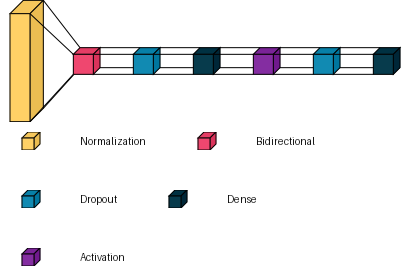

In [44]:
import visualkeras
from PIL import ImageFont
from IPython.display import display
import os

# Create a 3D-style visualization of the model
img = visualkeras.layered_view(
    model, 
    legend=True,
    spacing=40,
    draw_volume=True
)

# Display in notebook
display(img)


### Importing Libraries
This section loads all necessary Python libraries for data processing, machine learning, visualization, and neural network modeling.

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=200,
                    validation_data=val_ds,
                    callbacks=[early_stop])

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.2564 - mae: 0.3980 - val_loss: 10.6671 - val_mae: 0.6456
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6796 - mae: 0.2592 - val_loss: 9.5009 - val_mae: 0.6478
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.4647 - mae: 0.1922 - val_loss: 8.5162 - val_mae: 0.6279
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5544 - mae: 0.1677 - val_loss: 7.7838 - val_mae: 0.6169
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.8763 - mae: 0.1576 - val_loss: 7.2258 - val_mae: 0.6003
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4094 - mae: 0.1614 - val_loss: 6.9047 - val_mae: 0.6111
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0992 - mae: 0.1678 - val_loss: 6.6689 - val_mae: 0.6105
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9395 - mae: 0.1865 - val_loss: 6.5103 - val_mae: 0.6138
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - l

### Training Visualization
Plot model training and validation loss over epochs.

In [ ]:
plot_loglog_mae(history)
plot_training_history(history, log_scale=False)

## Plot RNN predictions

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
all_dirs = [
    #'datasets/256_Al/Dv1.0',
    #'datasets/Al_256_channel/Dv1.0',
    'datasets/Al_256_new/Dmin_v1.0',
    'datasets/Al_256_new/Dmod_v1.0',
    'datasets/Al_256_new/Doptimal_v1.0',
    'datasets/Al_256_new/Drnddir2_v1.0'
    ]

for d in range(len(all_dirs)):
    new_file_df = data[data['file'] == all_dirs[d]]

    # Make sure it's sorted by timestep
    new_file_df = new_file_df.sort_values('timestep')
    channel_new_file_df = new_file_df.sort_values('timestep')
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    
    y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
    y_pred = y_pred.flatten()
    print(f"Plot of {all_dirs[d]}")
    plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(0, 1000),
    log_scale=False
)

In [ ]:
# Load new data
new_file_df = random_data[random_data['file'] == 'datasets/256_Al/Dv1.0']  # or whatever new file

# sort by timestep
new_file_df = new_file_df.sort_values('timestep')


In [ ]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)

In [ ]:
y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(2000, 7000)
)

In [ ]:
# Load new data — it should look like your original df
new_file_df = channel_data[channel_data['file'] == 'datasets/Al_256_channel/Dv1.0']  # or whatever new file

# Make sure it's sorted by timestep
new_file_df = new_file_df.sort_values('timestep')


In [ ]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)

In [ ]:
y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(600, 1000)
)

### Old style graphs

In [ ]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True {y_col}\nMAE = {mae:.4f} $E_h$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error

y_true = new_file_df[y_col].values[timesteps:]  # shift due to prediction offset

mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 4))
plt.plot(y_true, label=f'True {y_col}', linewidth=2)
plt.plot(y_pred, label=f'Predicted {y_col}', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel(f'{y_col.capitalize()}')
plt.title(f'Predicted vs. True Energy\nMAE = {mae:.4f} $E_h$')
plt.legend()
plt.xlim(0,100)
plt.grid(True)
plt.tight_layout()
plt.show()

### Dense Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, InputLayer, BatchNormalization
from tensorflow.keras import regularizers

def build_simple_dense_model(input_shape, norm_layer=None):
    """
    Builds a simple dense neural network for sequential input.
    
    Parameters:
    - input_shape: tuple, e.g. (timesteps, num_features)
    - norm_layer: optional normalization layer (e.g., LayerNormalization or BatchNormalization)
    
    Returns:
    - compiled Keras model
    """
    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))

    if norm_layer is not None:
        model.add(norm_layer)

    model.add(Flatten())
    model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3)))
    model.add(Dropout(0.3))

    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model



In [ ]:
import numpy as np
from tensorflow.keras.layers import Normalization

# Step 1: Extract all X from train_ds
all_X = []

for X_batch, _ in train_ds:
    all_X.append(X_batch.numpy())  # Convert from tf.Tensor to NumPy

# Step 2: Concatenate and flatten
X_all = np.concatenate(all_X, axis=0)         # shape: (total_samples, timesteps, num_features)
X_flat = X_all.reshape(-1, X_all.shape[-1])   # shape: (total_samples * timesteps, num_features)

# Step 3: Create and adapt normalization layer
norm_layer = Normalization()
norm_layer.adapt(X_flat)  # Now norm_layer is ready to be used in your model

# Get one batch from the training dataset
for X_batch, y_batch in train_ds.take(1):
    input_shape = X_batch.shape[1:]  # exclude batch size

print("Input shape:", input_shape)

In [ ]:
K.clear_session()
dense_model = build_simple_dense_model(input_shape=input_shape, norm_layer=norm_layer)
model.summary()

In [ ]:
import visualkeras
from PIL import ImageFont, Image, ImageDraw
from IPython.display import display
import os
from matplotlib import pyplot as plt
import tensorflow.keras.layers as layers

# -------------------------
# Define Consistent Color Map
# -------------------------
color_map = {
    layers.InputLayer:         {"fill": (232, 233, 235)},  # Light Gray
    layers.Dense:              {"fill": (232, 74, 39)},    # Illinois Orange
    layers.LSTM:               {"fill": (19, 41, 75)},     # Illinois Blue
    layers.Bidirectional:      {"fill": (255, 127, 50)},   # Accent Orange
    layers.Dropout:            {"fill": (144, 144, 144)},  # Cool Gray
    layers.LayerNormalization: {"fill": (0, 95, 131)},     # Accent Blue (new!)
    layers.MultiHeadAttention: {"fill": (70, 130, 180)},   # Steel Blue
    layers.Reshape:            {"fill": (255, 204, 0)},    # Bright Gold
    layers.Add:                {"fill": (0, 139, 139)},    # Dark Cyan
    layers.Concatenate:        {"fill": (0, 191, 255)},    # Deep Sky Blue
    layers.Flatten:            {"fill": (0, 0, 0)},         # Black
}



# -------------------------
# Generate Visualizations
# -------------------------
img_lstm = visualkeras.layered_view(
    model,
    legend=True,
    spacing=40,
    draw_volume=True,
    color_map=color_map
)

img_transformer = visualkeras.layered_view(
    transformer_model,
    legend=True,
    spacing=40,
    draw_volume=True,
    color_map=color_map
)

img_dense = visualkeras.layered_view(
    dense_model,
    legend=True,
    spacing=40,
    draw_volume=True,
    color_map=color_map
)

# -------------------------
# Plot All Models Side-by-Side
# -------------------------
fig, axs = plt.subplots(1, 3, figsize=(30, 12))

axs[0].imshow(img_lstm)
axs[0].axis('off')
axs[0].set_title("Bidirectional LSTM", fontsize=18)

axs[1].imshow(img_transformer)
axs[1].axis('off')
axs[1].set_title("Transformer", fontsize=18)

axs[2].imshow(img_dense)
axs[2].axis('off')
axs[2].set_title("Dense Feedforward", fontsize=18)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()


### Model Training
Train the model on the training dataset while validating on the validation set.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=100,
                    validation_data=val_ds,
                    callbacks=[early_stop])
plot_training_history(history)

In [ ]:
# Load new data — it should look like your original df
new_file_df = random_data[random_data['file'] == 'datasets/256_Al/Dv1.0']  # or whatever new file

# Make sure it's sorted by timestep
new_file_df = new_file_df.sort_values('timestep')


In [ ]:
pred_sequences = []

for i in range(len(new_file_df) - timesteps):
    window = new_file_df.iloc[i:i+timesteps][X_cols].values
    pred_sequences.append(window)

X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)

In [ ]:
y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
y_pred = y_pred.flatten()

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(6000, 7000)
)

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
all_dirs = all_dirs = [
    'datasets/Al_256_new/Dmin_v1.0',
    'datasets/Al_256_new/Dmod_v1.0',
    'datasets/Al_256_new/Doptimal_v1.0',
    'datasets/Al_256_new/Drnddir2_v1.0'
    ]

for d in range(len(all_dirs)):
    new_file_df = data[data['file'] == all_dirs[d]]

    # Make sure it's sorted by timestep
    new_file_df = new_file_df.sort_values('timestep')
    channel_new_file_df = new_file_df.sort_values('timestep')
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    
    y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
    y_pred = y_pred.flatten()
    print(f"Plot of {all_dirs[d]}")
    plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(6000, 7000),
    log_scale=False
)

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

def build_tunable_dense_model(hp):
    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))  # <- comes from one batch in train_ds

    if norm_layer is not None:
        model.add(norm_layer)

    model.add(Flatten())

    # Choose number of layers: 1 to 4
    num_layers = hp.Int("num_layers", 1, 4)

    for i in range(num_layers):
        units = hp.Int(f"units_{i}", min_value=32, max_value=256, step=32)
        activation = hp.Choice("activation", ["relu", "tanh", "swish"])
        l2_val = hp.Float(f"l2_{i}", 1e-6, 1e-2, sampling="log")
        dropout_rate = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)

        model.add(Dense(units, activation=activation,
                        kernel_regularizer=regularizers.l2(l2_val)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))  # regression output

    learning_rate = hp.Float("lr", 1e-5, 1e-2, sampling="log")
    optimizer = hp.Choice("optimizer", ["adam", "rmsprop", "nadam"])

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


In [ ]:
tuner = kt.BayesianOptimization(
    build_tunable_dense_model,
    objective="val_loss",
    max_trials=70,
    directory="kt_logs",
    project_name="dense_bayes"
)



In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True)

tuner.search(train_ds,
             validation_data=val_ds,
             epochs=200,
             callbacks=[early_stop])


In [ ]:
K.clear_session()
model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
for hp in best_hps.values:
    print(f"{hp}: {best_hps.get(hp)}")

### Model Training
Train the model on the training dataset while validating on the validation set.

In [ ]:
best_hps = tuner.get_best_hyperparameters(1)[0]
model = build_tunable_dense_model(best_hps)
model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stop])


In [ ]:
plot_training_history(model)

### Prediction Visualization
Visualize model predictions against true values with zoom-in capability.

In [ ]:
all_dirs = all_dirs = [
    'datasets/Al_256_new/Dmin_v1.0',
    'datasets/Al_256_new/Dmod_v1.0',
    'datasets/Al_256_new/Doptimal_v1.0',
    'datasets/Al_256_new/Drnddir2_v1.0'
    ]

for d in range(len(all_dirs)):
    new_file_df = data[data['file'] == all_dirs[d]]

    # Make sure it's sorted by timestep
    new_file_df = new_file_df.sort_values('timestep')
    channel_new_file_df = new_file_df.sort_values('timestep')
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    pred_sequences = []

    for i in range(len(new_file_df) - timesteps):
        window = new_file_df.iloc[i:i+timesteps][X_cols].values
        pred_sequences.append(window)

    X_pred = np.array(pred_sequences)  # shape: (num_windows, timesteps, num_features)
    
    y_pred = model.predict(X_pred)  # shape: (num_windows, 1)
    y_pred = y_pred.flatten()
    print(f"Plot of {all_dirs[d]}")
    plot_predictions_with_zoom(
    y_true=new_file_df[y_col].values,
    y_pred=y_pred,
    y_col=y_col,
    offset=timesteps,
    zoom_range=(0, 1000),
    log_scale=False
)


---

## Summary

This notebook walks through the complete pipeline for training a neural network on QBox simulation data:

- **Library Imports**: Essential tools for ML, plotting, data handling, and deep learning.
- **Data Loading**: Loads structured simulation data
- **Preprocessing**: Splits data into training/validation and formats sequences for time-series modeling.
- **Modeling**: Defines a neural network using Keras with configurable architecture.
- **Training**: Optimizes the model using validation monitoring.
- **Evaluation**: Visualizes training history and prediction accuracy.

This workflow supports modular experimentation with various architectures and training regimes.

